#  Regresion: Predicción de ventas en una tienda de videojuegos
1. Preparación de Datos
2. División de los datos
3. Aprendizaje del Modelo
4. Evaluación del Modelo: MSE, RMSE, MAE, MAPE
5. Guardamos el modelo

In [107]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Preparación de Datos


In [108]:
#Cargamos los datos
data = pd.read_csv("videojuegos.csv")
data.head()

,videojuego,Edad,Sexo,Plataforma,Consumidor_habitual,Presupuesto para invertir
0,'Mass Effect',29,Mujer,PC,True,200
1,'Sim City',27,Mujer,Otros,True,600
2,'Dead Space',22,Hombre,'Xbox',False,200
3,'Battlefield',28,Mujer,'Xbox',True,370
4,'KOA: Reckoning',30,Mujer,PC,True,100


In [109]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   videojuego                 168 non-null    object
 1   Edad                       168 non-null    int64 
 2   Sexo                       168 non-null    object
 3   Plataforma                 168 non-null    object
 4   Consumidor_habitual        168 non-null    bool  
 5   Presupuesto para invertir  168 non-null    int64 
dtypes: bool(1), int64(2), object(3)
memory usage: 6.9+ KB


In [110]:
data['videojuego']=data['videojuego'].astype('category')
data['Sexo']=data['Sexo'].astype('category')
data['Plataforma']=data['Plataforma'].astype('category')

In [111]:
#Descripción de variables numéricas
data.describe()

,Edad,Presupuesto para invertir
count,168.000000,168.000000
mean,27.500000,311.547619
std,9.744644,294.440478
min,14.000000,10.000000
25%,19.000000,100.000000
50%,26.000000,215.000000
75%,33.000000,400.000000
max,52.000000,1200.000000


<Axes: >

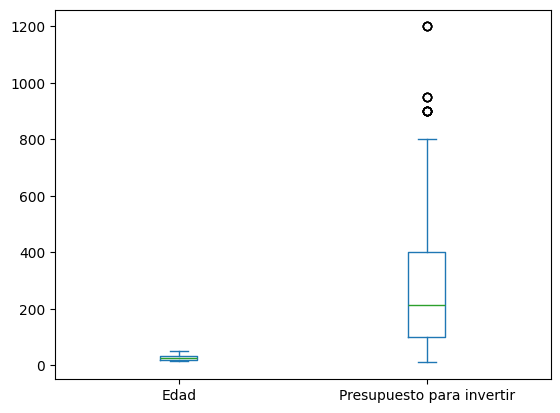

In [112]:
data.plot(kind='box')

<Axes: xlabel='videojuego'>

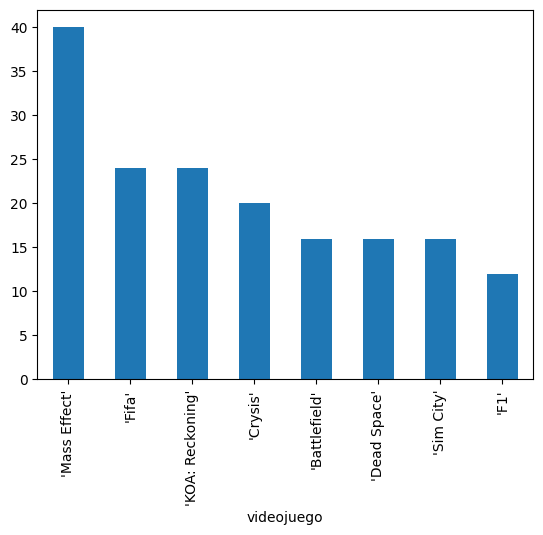

In [113]:
#Descripción variables categóricas
data['videojuego'].value_counts().plot(kind='bar')

<Axes: xlabel='Plataforma'>

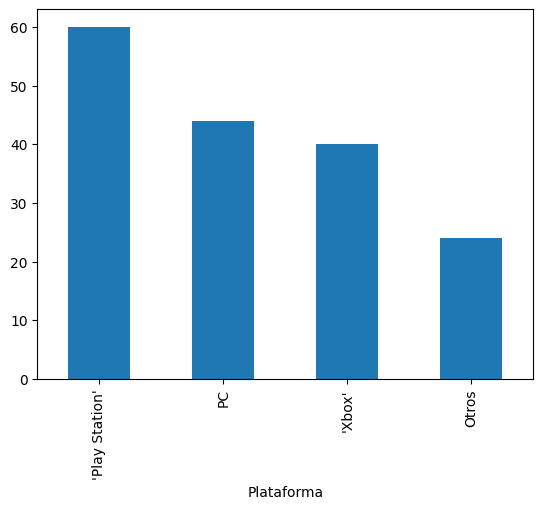

In [114]:
data['Plataforma'].value_counts().plot(kind='bar')

<Axes: xlabel='Consumidor_habitual'>

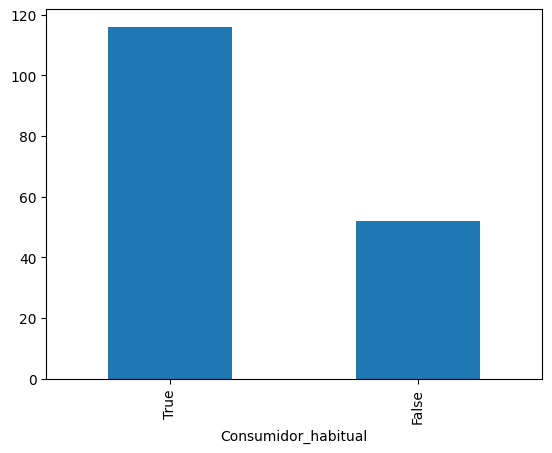

In [115]:
data['Consumidor_habitual'].value_counts().plot(kind='bar')

In [116]:
#Creamos variables dummy para convertir  las categorías a números
data = pd.get_dummies(data, columns=['videojuego', 'Plataforma'], drop_first=False, dtype=int)
data = pd.get_dummies(data, columns=['Sexo', 'Consumidor_habitual'], drop_first=True, dtype=int)
data.head()

,Edad,Presupuesto para invertir,videojuego_'Battlefield',videojuego_'Crysis',videojuego_'Dead Space',videojuego_'F1',videojuego_'Fifa',videojuego_'KOA: Reckoning',videojuego_'Mass Effect',videojuego_'Sim City',Plataforma_'Play Station',Plataforma_'Xbox',Plataforma_Otros,Plataforma_PC,Sexo_Mujer,Consumidor_habitual_True
0,29,200,0,0,0,0,0,0,1,0,0,0,0,1,1,1
1,27,600,0,0,0,0,0,0,0,1,0,0,1,0,1,1
2,22,200,0,0,1,0,0,0,0,0,0,1,0,0,0,0
3,28,370,1,0,0,0,0,0,0,0,0,1,0,0,1,1
4,30,100,0,0,0,0,0,1,0,0,0,0,0,1,1,1


In [117]:
#LaberEncoder es solo para clasificación pues la variable aquí ya es numérica

# 2. División 70-30


<Axes: >

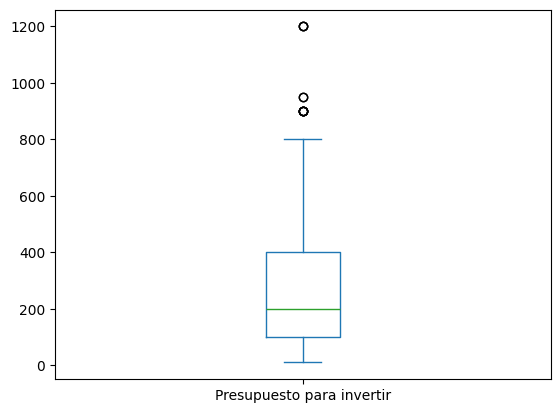

In [118]:
#División 70-30
from sklearn.model_selection import train_test_split
X = data.drop("Presupuesto para invertir", axis = 1) # Variables predictoras
Y = data['Presupuesto para invertir'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=None) #startify none porque es regresión
Y_train.plot(kind='box')

<Axes: ylabel='Frequency'>

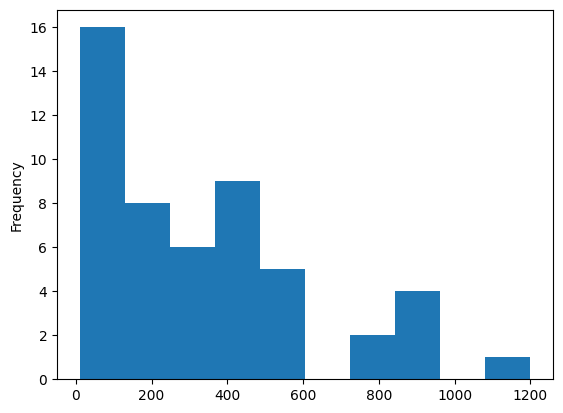

In [119]:
# Variable objetivo del 30% - hist
Y_test.plot(kind='hist')

# 3. Aprendizaje  70% y Evaluación 30%

In [120]:
#Dataframe para comparar los resultados
medidas= pd.DataFrame(index=['mse','rmse','mae','mape','max'])

# Arbol de Regresión
-No se normaliza

In [121]:
#Creación del modelo con el conjunto de entrenamiento
from sklearn.tree import DecisionTreeRegressor
model_Tree = DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=2, max_depth=None)
model_Tree.fit(X_train, Y_train)#70% entrenamiento


DecisionTreeRegressor(min_samples_leaf=2)

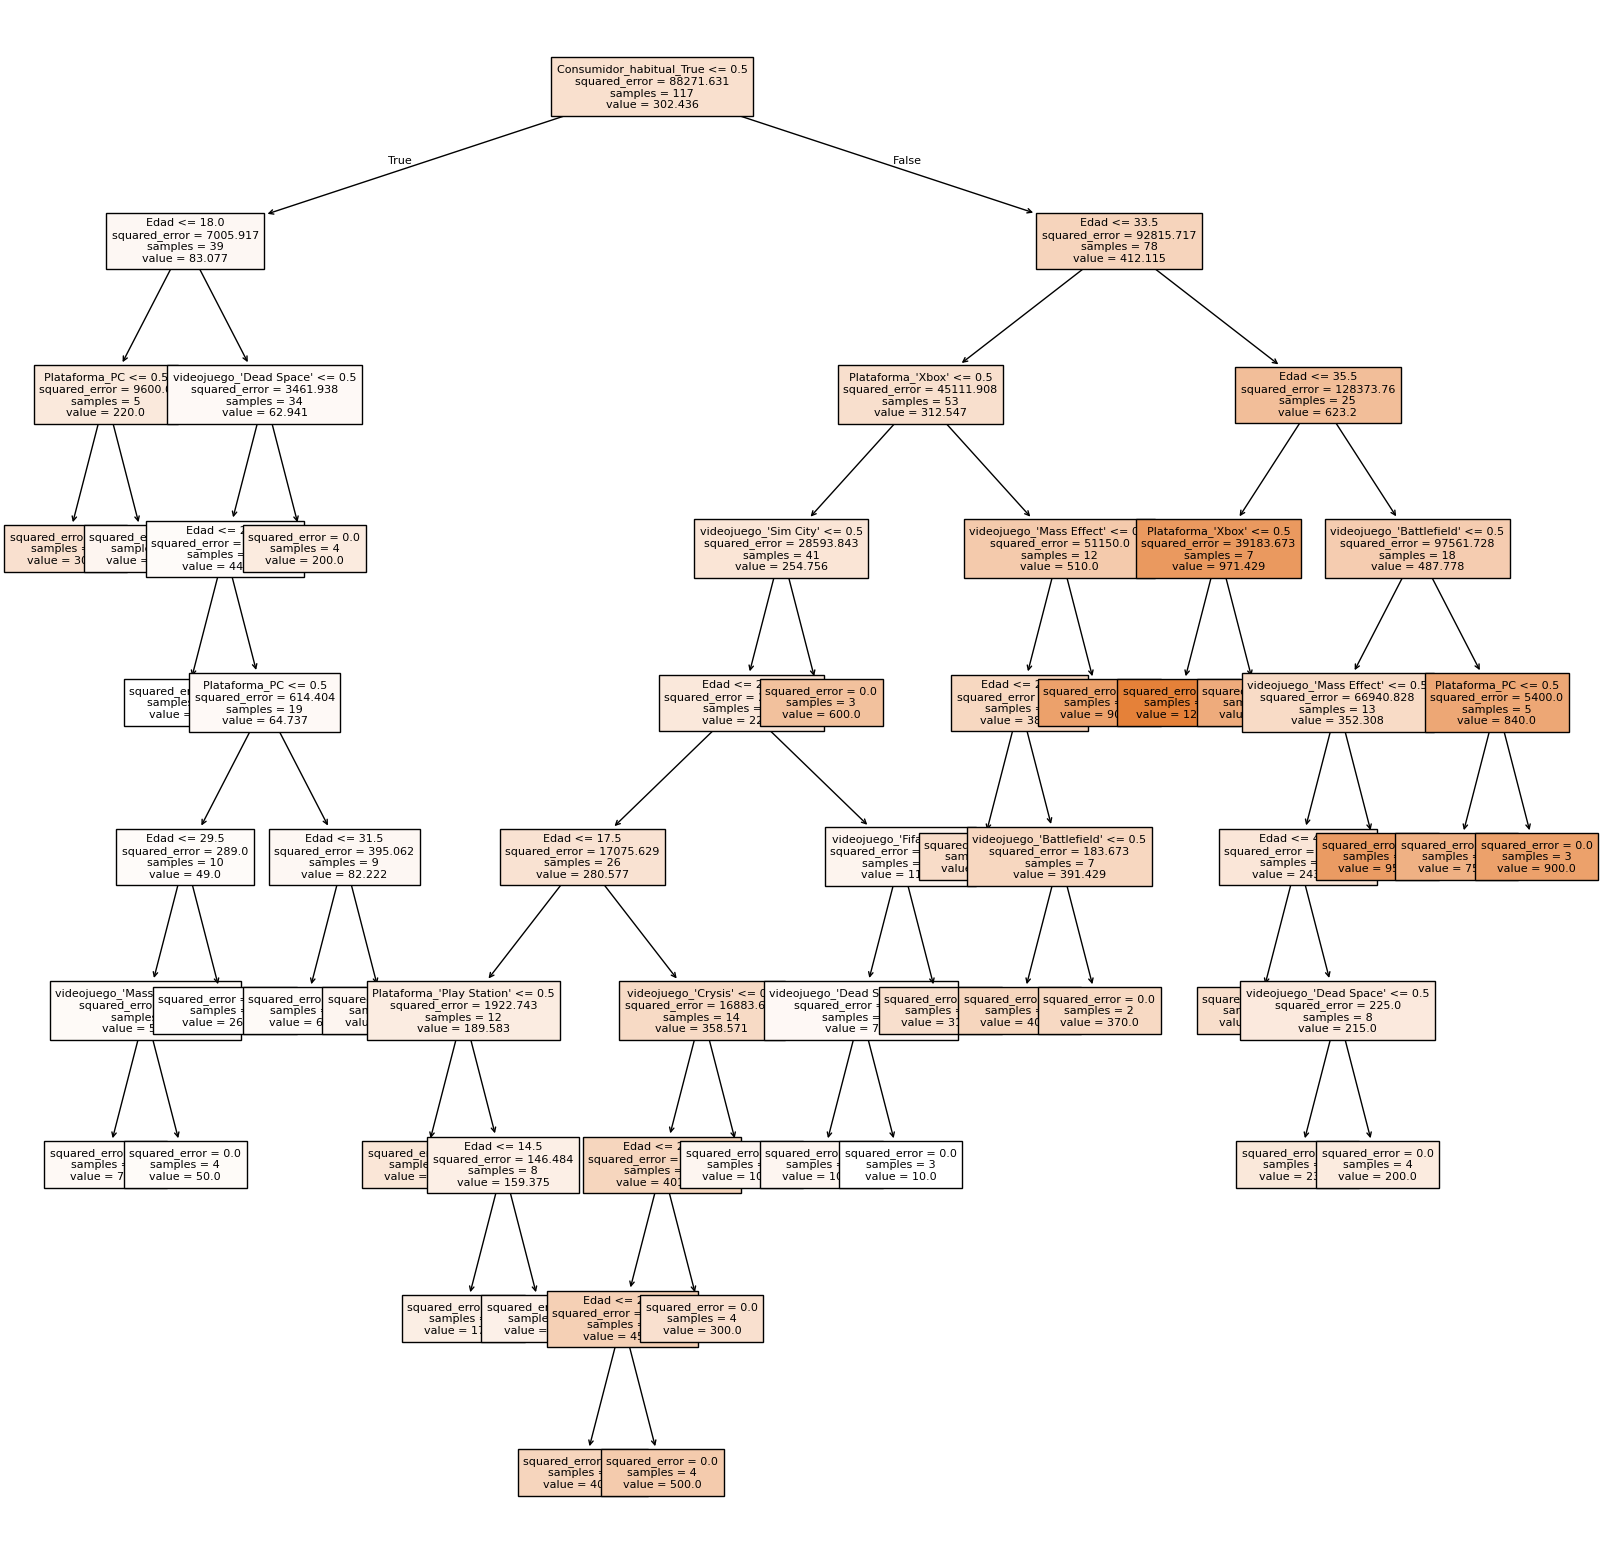

In [122]:
#Graficar el árbol
from sklearn.tree import plot_tree
nombres_variables=X_train.columns.values
plt.figure(figsize=(20,20))
plot_tree(model_Tree, feature_names=nombres_variables, filled=True,fontsize=8)
plt.show()

In [123]:
#Evaluación del árbol 30%
from sklearn import metrics
Y_pred = model_Tree.predict(X_test) #30%

#Medidas de evaluación en regresión
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred) #Verificar si la objetivo es 0
max=metrics.max_error(Y_test,Y_pred)
medidas['Arbol']=[mse, rmse, mae, mape,max]
medidas

,Arbol
mse,801.089325
rmse,28.303521
mae,9.346405
mape,0.065527
max,100.000000


/tmp/ipykernel_3030/2783684465.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


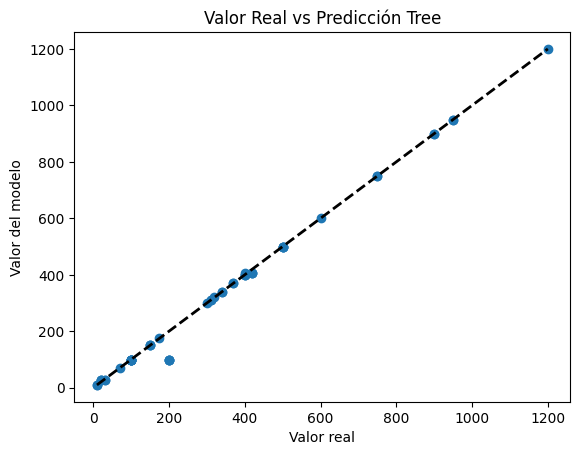

In [124]:
#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Tree')
plt.show() # Mostrar la grafica luego de que ya se definio todos los elementos

# KNN para Regresión
* Normalización de las var numéricas

In [125]:
#Normalizacion de las variables numéricas (las dummies no se normalizan)
#Normalizacion de las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

variables_numericas=['Edad']

#Ajuste de los parametros sobre 100% de los datos (data): max - min
min_max_scaler.fit(data[variables_numericas])

#Se aplica la normalización a 70%  y 30%
X_train[variables_numericas]= min_max_scaler.transform(X_train[variables_numericas]) #70%
X_test[variables_numericas]= min_max_scaler.transform(X_test[variables_numericas]) #30%
X_train.head()


,Edad,videojuego_'Battlefield',videojuego_'Crysis',videojuego_'Dead Space',videojuego_'F1',videojuego_'Fifa',videojuego_'KOA: Reckoning',videojuego_'Mass Effect',videojuego_'Sim City',Plataforma_'Play Station',Plataforma_'Xbox',Plataforma_Otros,Plataforma_PC,Sexo_Mujer,Consumidor_habitual_True
63,0.315789,0,0,0,0,0,0,1,0,1,0,0,0,0,0
163,0.131579,0,0,0,0,1,0,0,0,0,0,1,0,0,1
33,0.184211,0,0,0,1,0,0,0,0,1,0,0,0,1,1
105,0.315789,0,0,0,0,0,0,1,0,1,0,0,0,0,0
117,0.184211,0,0,0,1,0,0,0,0,1,0,0,0,1,1


In [126]:
from sklearn.neighbors import  KNeighborsRegressor
model_Knn = KNeighborsRegressor(n_neighbors=3, metric='euclidean') #minkowski
model_Knn.fit(X_train, Y_train) #70%

KNeighborsRegressor(metric='euclidean', n_neighbors=3)

           Arbol           Knn
mse   801.089325  11931.263617
rmse   28.303521    109.230324
mae     9.346405     73.921569
mape    0.065527      0.340884
max   100.000000    273.333333


/tmp/ipykernel_3030/73678959.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


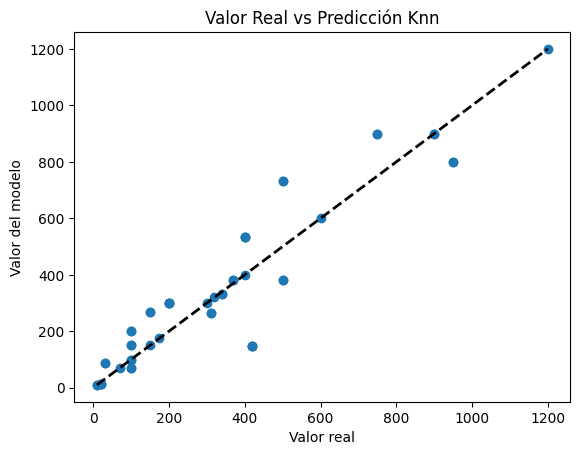

In [127]:
#Evaluación de KNN
from sklearn import metrics

Y_pred = model_Knn.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['Knn']=[mse, rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Knn')
plt.show()

# Red Neuronal para Regresión
- Normalizar

In [128]:
from sklearn.neural_network import MLPRegressor

#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: sigmoid, logistic, linear, relu
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#momentum-> valor momentum
#max_iter-> iteaciones
#random_state-> semilla para generacion numeros seudoaletorios

model_NN = MLPRegressor(activation="relu",hidden_layer_sizes=(12,7,3), learning_rate='adaptive',
                     learning_rate_init=0.05, momentum= 0.02, max_iter=500,  random_state=3)

model_NN.fit(X_train, Y_train)#70%

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(12, 7, 3), learning_rate='adaptive',
             learning_rate_init=0.05, max_iter=500, momentum=0.02,
             random_state=3)

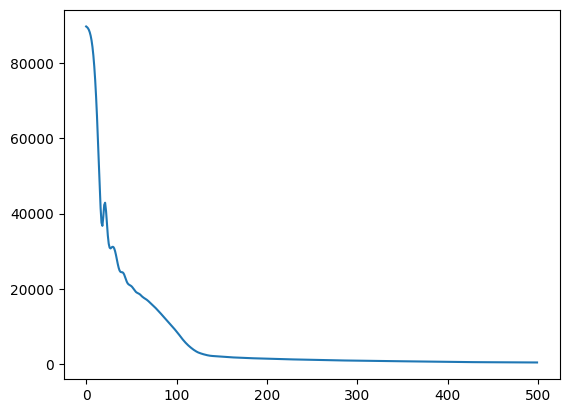

In [129]:
#Loss es la desviación entre Y_train y el Y_pred
loss_values = model_NN.loss_curve_
plt.plot(loss_values)

/tmp/ipykernel_3030/1852016271.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


           Arbol           Knn                 NN
mse   801.089325  11931.263617  4799.147934198799
rmse   28.303521    109.230324          69.275883
mae     9.346405     73.921569          38.260685
mape    0.065527      0.340884           0.296363
max   100.000000    273.333333         200.761268


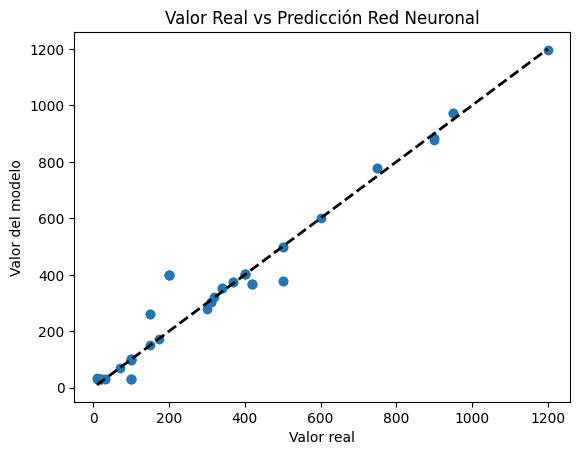

In [130]:
#Evaluación de NN
from sklearn import metrics

Y_pred = model_NN.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['NN']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Red Neuronal')
plt.show()

# SVM para Regresión - SVR

-Normalizar

In [131]:
#SVR

#Kernel='linear', 'poly', 'rbf', 'sigmoid', 'precomputed'



#SVM

from sklearn.svm import SVR



modelSVM = SVR(kernel='sigmoid', C=3) #'linear', 'poly'->degree, 'rbf', 'sigmoid', 'precomputed'

modelSVM.fit(X_train, Y_train) #70%



SVR(C=3, kernel='sigmoid')

           Arbol           Knn                 NN                SVM
mse   801.089325  11931.263617  4799.147934198799  89024.08049875991
rmse   28.303521    109.230324          69.275883         298.369034
mae     9.346405     73.921569          38.260685         213.301821
mape    0.065527      0.340884           0.296363           2.037976
max   100.000000    273.333333         200.761268         974.728682


/tmp/ipykernel_3030/2933959338.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


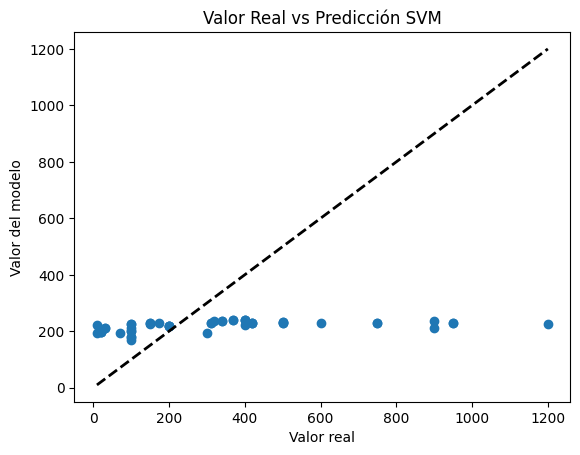

In [132]:
#Evaluación de SVM
from sklearn import metrics

Y_pred = modelSVM.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['SVM']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción SVM')
plt.show()


# Regresión Lineal
-Normalizar

In [133]:
from sklearn.linear_model import LinearRegression

model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)

LinearRegression()

           Arbol           Knn                 NN                SVM  \
mse   801.089325  11931.263617  4799.147934198799  89024.08049875991   
rmse   28.303521    109.230324          69.275883         298.369034   
mae     9.346405     73.921569          38.260685         213.301821   
mape    0.065527      0.340884           0.296363           2.037976   
max   100.000000    273.333333         200.761268         974.728682   

                      LR  
mse   45482.428614531826  
rmse          213.266098  
mae           186.298083  
mape            2.229834  
max           470.904814  


/tmp/ipykernel_3030/2449743100.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


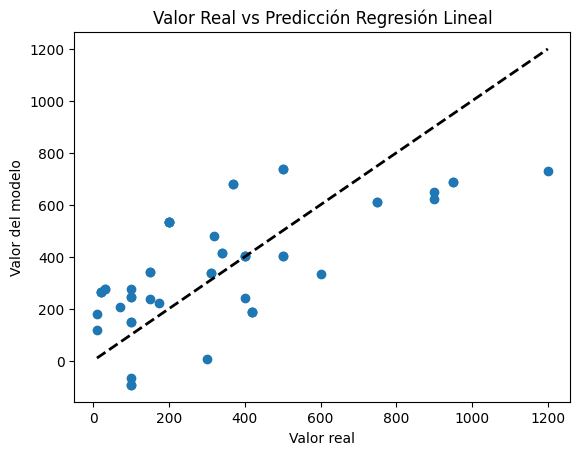

In [134]:
#Evaluación de RL
from sklearn import metrics

Y_pred = model_LR.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['LR']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Regresión Lineal')
plt.show()

# 4. Guardamos el modelo seleccionado
Se entrena modelo final con 100% de los datos (X,Y)

In [135]:
medidas

,Arbol,Knn,NN,SVM,LR
mse,801.089325,11931.263617,4799.147934198799,89024.08049875991,45482.428614531826
rmse,28.303521,109.230324,69.275883,298.369034,213.266098
mae,9.346405,73.921569,38.260685,213.301821,186.298083
mape,0.065527,0.340884,0.296363,2.037976,2.229834
max,100.000000,273.333333,200.761268,974.728682,470.904814


Selección de modelo: De acuerdo al mape, el modelo que tiene mejor dese,peño es la red neuronal con un 22,31% pero el arbol nos da 23,13. Basandonos en costos operativos y complejidad el arbol es la mejor opción en este caso.  :)

In [136]:
#Normalizar X en caso de ser necesario: Knn, NN, SVM, Reg
#X[variables_numericas]= min_max_scaler.transform(X[variables_numericas])

In [137]:
#Entrenamos modelo final
model_Tree.fit(X, Y) #100%

DecisionTreeRegressor(min_samples_leaf=2)

In [138]:
import pickle
filename = 'modelo-reg.pkl'
variables=X.columns._values
pickle.dump([model_NN, min_max_scaler,variables], open(filename, 'wb'))